In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

OUTPUT_07_DIR = PROJECT_ROOT / "Outputs" / "07_stress_scenario_analysis"
OUTPUT_08_DIR = PROJECT_ROOT / "Outputs" / "08_tail_risk_portfolio_metrics"
OUTPUT_09_DIR = PROJECT_ROOT / "Outputs" / "09_final_model_comparison_and_results_tables"
OUTPUT_09_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Notebook 07 output directory:", OUTPUT_07_DIR)
print("Notebook 08 output directory:", OUTPUT_08_DIR)
print("Notebook 09 output directory:", OUTPUT_09_DIR)

Project root: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance
Notebook 07 output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\07_stress_scenario_analysis
Notebook 08 output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\08_tail_risk_portfolio_metrics
Notebook 09 output directory: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables


In [2]:
def read_required_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found: {path}\n"
            "Run notebooks 07 and 08 first, then rerun this notebook."
        )

    return pd.read_csv(path)


def read_optional_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None

    return pd.read_csv(path)


def validate_columns(df: pd.DataFrame, required_columns: list[str], table_name: str) -> None:
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(
            f"{table_name} is missing required columns: {missing_columns}"
        )


def display_table(title: str, df: pd.DataFrame, n: int | None = None, round_digits: int = 4) -> None:
    print(title)
    if n is None:
        display(df.round(round_digits))
    else:
        display(df.head(n).round(round_digits))


def order_scenario_table(df: pd.DataFrame) -> pd.DataFrame:
    output = df.copy()

    scenario_type_order = ["baseline", "hospitalisation", "chronic_disease", "combined"]
    severity_order = ["baseline", "mild", "moderate", "severe"]

    if "scenario_type" in output.columns:
        output["scenario_type"] = pd.Categorical(
            output["scenario_type"],
            categories=scenario_type_order,
            ordered=True,
        )

    if "severity" in output.columns:
        output["severity"] = pd.Categorical(
            output["severity"],
            categories=severity_order,
            ordered=True,
        )

    sort_cols = [col for col in ["scenario_type", "severity", "scenario"] if col in output.columns]

    if sort_cols:
        output = output.sort_values(sort_cols).reset_index(drop=True)

    return output


def add_percentage_columns(
        df: pd.DataFrame,
        proportion_columns: list[str],
        suffix: str = "_pct",
) -> pd.DataFrame:
    output = df.copy()

    for col in proportion_columns:
        if col in output.columns:
            output[f"{col}{suffix}"] = output[col] * 100

    return output


def _get_numeric_column_values(df: pd.DataFrame, column: str) -> np.ndarray:
    matching_positions = [
        position
        for position, column_name in enumerate(df.columns)
        if column_name == column
    ]

    if not matching_positions:
        raise ValueError(f"Column '{column}' was not found.")

    if len(matching_positions) > 1:
        raise ValueError(f"Column '{column}' is duplicated in the dataframe.")

    column_position = matching_positions[0]

    column_values = df.iloc[:, column_position]

    numeric_values = np.asarray(
        pd.to_numeric(column_values, errors="coerce"),
        dtype=float,
    )

    if numeric_values.size == 0:
        raise ValueError(f"Column '{column}' contains no values.")

    if np.isnan(numeric_values).all():
        raise ValueError(f"Column '{column}' contains no numeric values.")

    return numeric_values


def safe_abs_min_row(df: pd.DataFrame, column: str) -> pd.Series:
    numeric_values = _get_numeric_column_values(df, column)

    position = int(
        np.nanargmin(
            np.abs(numeric_values)
        )
    )

    return df.iloc[position].copy()


def safe_min_row(df: pd.DataFrame, column: str) -> pd.Series:
    numeric_values = _get_numeric_column_values(df, column)

    position = int(
        np.nanargmin(numeric_values)
    )

    return df.iloc[position].copy()


def save_final_table(df: pd.DataFrame, filename: str) -> Path:
    path = OUTPUT_09_DIR / filename
    df.to_csv(path, index=False)
    return path

In [3]:
stress_scenario_summary_df = read_required_csv(OUTPUT_07_DIR / "stress_scenario_summaries.csv")
stress_scenario_comparison_df = read_required_csv(OUTPUT_07_DIR / "stress_scenario_comparison.csv")
stress_aggregate_response_df = read_required_csv(OUTPUT_07_DIR / "stress_aggregate_response_table.csv")
stress_tail_response_df = read_required_csv(OUTPUT_07_DIR / "stress_tail_response_table.csv")
baseline_portfolio_predictions_df = read_required_csv(OUTPUT_07_DIR / "baseline_portfolio_predictions.csv")

stress_scenario_predictions_wide_df = read_optional_csv(
    OUTPUT_07_DIR / "stress_scenario_predictions_wide.csv"
)

model_performance_df = read_required_csv(OUTPUT_08_DIR / "tail_risk_model_performance.csv")
mean_model_tail_risk_results_df = read_required_csv(OUTPUT_08_DIR / "mean_model_tail_risk_results_table.csv")
tail_metric_detail_df = read_required_csv(OUTPUT_08_DIR / "tail_risk_metric_detail.csv")
quantile_calibration_df = read_required_csv(OUTPUT_08_DIR / "quantile_model_calibration.csv")
quantile_crossing_summary_df = read_required_csv(OUTPUT_08_DIR / "quantile_crossing_summary.csv")
tail_risk_predictions_wide_df = read_required_csv(OUTPUT_08_DIR / "tail_risk_predictions_wide.csv")

loaded_tables = pd.DataFrame(
    [
        {"table": "stress_scenario_summary_df", "rows": len(stress_scenario_summary_df),
         "columns": stress_scenario_summary_df.shape[1]},
        {"table": "stress_scenario_comparison_df", "rows": len(stress_scenario_comparison_df),
         "columns": stress_scenario_comparison_df.shape[1]},
        {"table": "stress_aggregate_response_df", "rows": len(stress_aggregate_response_df),
         "columns": stress_aggregate_response_df.shape[1]},
        {"table": "stress_tail_response_df", "rows": len(stress_tail_response_df),
         "columns": stress_tail_response_df.shape[1]},
        {"table": "baseline_portfolio_predictions_df", "rows": len(baseline_portfolio_predictions_df),
         "columns": baseline_portfolio_predictions_df.shape[1]},
        {"table": "stress_scenario_predictions_wide_df",
         "rows": 0 if stress_scenario_predictions_wide_df is None else len(stress_scenario_predictions_wide_df),
         "columns": 0 if stress_scenario_predictions_wide_df is None else stress_scenario_predictions_wide_df.shape[1]},
        {"table": "model_performance_df", "rows": len(model_performance_df), "columns": model_performance_df.shape[1]},
        {"table": "mean_model_tail_risk_results_df", "rows": len(mean_model_tail_risk_results_df),
         "columns": mean_model_tail_risk_results_df.shape[1]},
        {"table": "tail_metric_detail_df", "rows": len(tail_metric_detail_df),
         "columns": tail_metric_detail_df.shape[1]},
        {"table": "quantile_calibration_df", "rows": len(quantile_calibration_df),
         "columns": quantile_calibration_df.shape[1]},
        {"table": "quantile_crossing_summary_df", "rows": len(quantile_crossing_summary_df),
         "columns": quantile_crossing_summary_df.shape[1]},
        {"table": "tail_risk_predictions_wide_df", "rows": len(tail_risk_predictions_wide_df),
         "columns": tail_risk_predictions_wide_df.shape[1]},
    ]
)

display(loaded_tables)

,table,rows,columns
0,stress_scenario_summary_df,10,21
1,stress_scenario_comparison_df,10,45
2,stress_aggregate_response_df,10,12
3,stress_tail_response_df,10,16
4,baseline_portfolio_predictions_df,100000,2
5,stress_scenario_predictions_wide_df,100000,10
6,model_performance_df,8,64
7,mean_model_tail_risk_results_df,5,19
8,tail_metric_detail_df,24,19
9,quantile_calibration_df,3,9


In [4]:
validate_columns(
    stress_aggregate_response_df,
    [
        "scenario",
        "scenario_type",
        "severity",
        "stress_fraction",
        "total_predicted_cost",
        "total_predicted_cost_change",
        "total_predicted_cost_pct_change",
        "mean_predicted_cost",
        "mean_predicted_cost_change",
    ],
    "stress_aggregate_response_df",
)

validate_columns(
    stress_tail_response_df,
    [
        "scenario",
        "scenario_type",
        "severity",
        "p90_predicted_cost",
        "p90_predicted_cost_change",
        "p95_predicted_cost",
        "p95_predicted_cost_change",
        "p99_predicted_cost",
        "p99_predicted_cost_change",
        "tail_concentration_p95",
        "tail_concentration_p95_change",
        "tvar_p95",
        "tvar_p95_change",
        "tvar_p99",
        "tvar_p99_change",
    ],
    "stress_tail_response_df",
)

validate_columns(
    model_performance_df,
    [
        "model_name",
        "model_family",
        "is_quantile_model",
        "weighted",
        "RMSE",
        "MAE",
        "R2",
        "bias",
        "SDEP",
        "Pearson correlation",
        "p90_underprediction",
        "p95_underprediction",
        "p99_underprediction",
        "top_10_pct_MAE",
        "top_5_pct_MAE",
        "top_1_pct_MAE",
        "distribution_tvar_underprediction_p95",
        "distribution_tvar_underprediction_p99",
        "distribution_tail_concentration_error_p95",
        "distribution_tail_concentration_error_p99",
    ],
    "model_performance_df",
)

validate_columns(
    quantile_calibration_df,
    [
        "model_name",
        "target_quantile",
        "observed_coverage",
        "coverage_error",
        "pinball_loss",
    ],
    "quantile_calibration_df",
)

validate_columns(
    quantile_crossing_summary_df,
    ["diagnostic", "n_crossings", "crossing_rate"],
    "quantile_crossing_summary_df",
)

print("All required outputs are available and contain the expected columns.")

All required outputs are available and contain the expected columns.


In [5]:
mean_model_performance_df = model_performance_df[
    ~model_performance_df["is_quantile_model"].astype(bool)
].copy()

average_performance_columns = [
    "model_name",
    "model_family",
    "weighted",
    "RMSE",
    "MAE",
    "R2",
    "bias",
    "SDEP",
    "Pearson correlation",
    "mean_actual_cost",
    "mean_predicted_cost",
]

final_average_model_performance_df = mean_model_performance_df[
    average_performance_columns
].copy()

final_average_model_performance_df["RMSE_rank"] = final_average_model_performance_df["RMSE"].rank(method="min")
final_average_model_performance_df["MAE_rank"] = final_average_model_performance_df["MAE"].rank(method="min")
final_average_model_performance_df["abs_bias"] = final_average_model_performance_df["bias"].abs()
final_average_model_performance_df["abs_bias_rank"] = final_average_model_performance_df["abs_bias"].rank(method="min")

final_average_model_performance_df = final_average_model_performance_df.sort_values(
    ["RMSE", "MAE"]
).reset_index(drop=True)

display_table("Final average predictive performance table", final_average_model_performance_df)

Final average predictive performance table


,model_name,model_family,weighted,RMSE,MAE,R2,bias,SDEP,Pearson correlation,mean_actual_cost,mean_predicted_cost,RMSE_rank,MAE_rank,abs_bias,abs_bias_rank
0,gb_tail_weighted,gradient_boosting,True,2937.3652,1861.5766,0.1232,-113.7816,2935.2340,0.4156,3027.7912,3141.5728,1.0,4.0,113.7816,1.0
1,ridge_baseline_grouped,ridge,False,2956.1487,1663.4470,0.1119,754.0958,2858.4197,0.4195,3027.7912,2273.6953,2.0,3.0,754.0958,3.0
2,gb_regularised_grouped,gradient_boosting,False,2968.2352,1658.5439,0.1046,765.8570,2867.8031,0.4213,3027.7912,2261.9342,3.0,1.0,765.8570,4.0
3,gb_baseline_grouped,gradient_boosting,False,2970.5019,1659.4716,0.1033,765.9035,2870.1368,0.4193,3027.7912,2261.8877,4.0,2.0,765.9035,5.0
4,ridge_tail_weighted,ridge,True,3042.4785,1885.3089,0.0593,-150.4843,3038.8306,0.4095,3027.7912,3178.2754,5.0,5.0,150.4843,2.0


In [6]:
tail_risk_columns = [
    "model_name",
    "model_family",
    "weighted",
    "top_10_pct_MAE",
    "top_5_pct_MAE",
    "top_1_pct_MAE",
    "p90_underprediction",
    "p95_underprediction",
    "p99_underprediction",
    "distribution_tvar_underprediction_p95",
    "distribution_tvar_underprediction_p99",
    "distribution_tail_concentration_error_p95",
    "distribution_tail_concentration_error_p99",
]

final_tail_risk_performance_df = mean_model_performance_df[tail_risk_columns].copy()

for col in [
    "p90_underprediction",
    "p95_underprediction",
    "p99_underprediction",
    "distribution_tvar_underprediction_p95",
    "distribution_tvar_underprediction_p99",
    "distribution_tail_concentration_error_p95",
    "distribution_tail_concentration_error_p99",
]:
    final_tail_risk_performance_df[f"abs_{col}"] = final_tail_risk_performance_df[col].abs()

final_tail_risk_performance_df["p95_underprediction_abs_rank"] = final_tail_risk_performance_df[
    "abs_p95_underprediction"
].rank(method="min")
final_tail_risk_performance_df["p99_underprediction_abs_rank"] = final_tail_risk_performance_df[
    "abs_p99_underprediction"
].rank(method="min")
final_tail_risk_performance_df["p99_TVaR_abs_rank"] = final_tail_risk_performance_df[
    "abs_distribution_tvar_underprediction_p99"
].rank(method="min")

final_tail_risk_performance_df = final_tail_risk_performance_df.sort_values(
    ["p95_underprediction_abs_rank", "p99_underprediction_abs_rank", "p99_TVaR_abs_rank"]
).reset_index(drop=True)

display_table("Final tail-risk performance table", final_tail_risk_performance_df)

Final tail-risk performance table


,model_name,model_family,weighted,top_10_pct_MAE,top_5_pct_MAE,top_1_pct_MAE,p90_underprediction,p95_underprediction,p99_underprediction,distribution_tvar_underprediction_p95,...,abs_p90_underprediction,abs_p95_underprediction,abs_p99_underprediction,abs_distribution_tvar_underprediction_p95,abs_distribution_tvar_underprediction_p99,abs_distribution_tail_concentration_error_p95,abs_distribution_tail_concentration_error_p99,p95_underprediction_abs_rank,p99_underprediction_abs_rank,p99_TVaR_abs_rank
0,gb_tail_weighted,gradient_boosting,True,5453.1829,7576.1149,14745.7051,360.5102,1179.4472,5453.7029,4063.2466,...,360.5102,1179.4472,5453.7029,4063.2466,10124.8964,0.0724,0.0348,1.0,2.0,2.0
1,ridge_tail_weighted,ridge,True,5628.4030,7659.4251,13955.5319,689.0763,1412.3991,2748.7397,2538.1826,...,689.0763,1412.3991,2748.7397,2538.1826,4808.2099,0.0501,0.0184,2.0,1.0,1.0
2,ridge_baseline_grouped,ridge,False,6919.0990,9432.3320,17030.9310,2777.0308,4411.2140,8872.1441,7504.3515,...,2777.0308,4411.2140,8872.1441,7504.3515,13576.5794,0.0939,0.0365,3.0,3.0,3.0
3,gb_baseline_grouped,gradient_boosting,False,7013.8038,9603.5049,17383.5550,2717.6509,4475.3400,9947.2362,8123.9776,...,2717.6509,4475.3400,9947.2362,8123.9776,15369.9653,0.1070,0.0442,4.0,5.0,5.0
4,gb_regularised_grouped,gradient_boosting,False,7007.8571,9593.8624,17352.0542,2713.2922,4530.4687,9914.5834,8135.6971,...,2713.2922,4530.4687,9914.5834,8135.6971,15229.1307,0.1072,0.0436,5.0,4.0,4.0


In [7]:
final_quantile_model_diagnostics_df = quantile_calibration_df.copy()
final_quantile_model_diagnostics_df["tail_level"] = final_quantile_model_diagnostics_df[
    "target_quantile"
].apply(lambda q: f"p{int(round(q * 100))}")
final_quantile_model_diagnostics_df["absolute_coverage_error"] = final_quantile_model_diagnostics_df[
    "coverage_error"
].abs()

final_quantile_model_diagnostics_df = final_quantile_model_diagnostics_df[
    [
        "model_name",
        "tail_level",
        "target_quantile",
        "observed_coverage",
        "coverage_error",
        "absolute_coverage_error",
        "pinball_loss",
        "mean_predicted_quantile",
        "median_predicted_quantile",
        "min_predicted_quantile",
        "max_predicted_quantile",
    ]
].sort_values("target_quantile").reset_index(drop=True)

final_quantile_crossing_summary_df = quantile_crossing_summary_df.copy()

display_table("Final quantile model diagnostics", final_quantile_model_diagnostics_df)
display_table("Final quantile crossing summary", final_quantile_crossing_summary_df)

Final quantile model diagnostics


,model_name,tail_level,target_quantile,observed_coverage,coverage_error,absolute_coverage_error,pinball_loss,mean_predicted_quantile,median_predicted_quantile,min_predicted_quantile,max_predicted_quantile
0,gb_quantile_p90,p90,0.90,0.8960,-0.0040,0.0040,598.8689,5879.7270,5392.8779,2009.2552,21353.9453
1,gb_quantile_p95,p95,0.95,0.9467,-0.0033,0.0033,409.0378,7725.6606,7156.4004,2900.7908,31437.3886
2,gb_quantile_p99,p99,0.99,0.9892,-0.0008,0.0008,142.2076,12763.0922,12008.0736,5991.4997,38178.2977


Final quantile crossing summary


,diagnostic,n_crossings,crossing_rate
0,p90_gt_p95,0,0.0
1,p95_gt_p99,1,0.0
2,p90_gt_p99,0,0.0
3,any_crossing,1,0.0


In [8]:
final_stress_aggregate_response_df = order_scenario_table(stress_aggregate_response_df)

final_stress_aggregate_response_df = add_percentage_columns(
    final_stress_aggregate_response_df,
    proportion_columns=[
        "total_predicted_cost_pct_change",
        "mean_predicted_cost_pct_change",
    ],
    suffix="_percent",
)

stress_aggregate_display_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "n_hospitalisation_shifted",
    "n_chronic_shifted",
    "total_predicted_cost",
    "total_predicted_cost_change",
    "total_predicted_cost_pct_change_percent",
    "mean_predicted_cost",
    "mean_predicted_cost_change",
    "mean_predicted_cost_pct_change_percent",
]

final_stress_aggregate_response_df = final_stress_aggregate_response_df[
    stress_aggregate_display_columns
].copy()

display_table("Final stress-scenario aggregate response table", final_stress_aggregate_response_df)

Final stress-scenario aggregate response table


,scenario,scenario_type,severity,stress_fraction,n_hospitalisation_shifted,n_chronic_shifted,total_predicted_cost,total_predicted_cost_change,total_predicted_cost_pct_change_percent,mean_predicted_cost,mean_predicted_cost_change,mean_predicted_cost_pct_change_percent
0,baseline,baseline,baseline,0.0,0,0,3.144176e+08,0.000000e+00,0.0000,3144.1761,0.0000,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1,9962,0,3.301713e+08,1.575373e+07,5.0104,3301.7134,157.5373,5.0104
2,hospitalisation_moderate,hospitalisation,moderate,0.2,19923,0,3.459356e+08,3.151798e+07,10.0242,3459.3560,315.1798,10.0242
3,hospitalisation_severe,hospitalisation,severe,0.3,29884,0,3.615515e+08,4.713391e+07,14.9909,3615.5152,471.3391,14.9909
4,chronic_disease_mild,chronic_disease,mild,0.1,0,9968,3.213428e+08,6.925202e+06,2.2025,3213.4281,69.2520,2.2025
5,chronic_disease_moderate,chronic_disease,moderate,0.2,0,19935,3.283083e+08,1.389068e+07,4.4179,3283.0829,138.9068,4.4179
6,chronic_disease_severe,chronic_disease,severe,0.3,0,29903,3.352081e+08,2.079053e+07,6.6124,3352.0814,207.9053,6.6124
7,combined_mild,combined,mild,0.1,9962,9968,3.371865e+08,2.276885e+07,7.2416,3371.8646,227.6885,7.2416
8,combined_moderate,combined,moderate,0.2,19923,19935,3.604683e+08,4.605066e+07,14.6463,3604.6827,460.5066,14.6463
9,combined_severe,combined,severe,0.3,29884,29903,3.841929e+08,6.977525e+07,22.1919,3841.9286,697.7525,22.1919


In [9]:
final_stress_tail_response_df = order_scenario_table(stress_tail_response_df)

stress_tail_display_columns = [
    "scenario",
    "scenario_type",
    "severity",
    "stress_fraction",
    "p90_predicted_cost",
    "p90_predicted_cost_change",
    "p95_predicted_cost",
    "p95_predicted_cost_change",
    "p99_predicted_cost",
    "p99_predicted_cost_change",
    "tail_concentration_p95",
    "tail_concentration_p95_change",
    "tvar_p95",
    "tvar_p95_change",
    "tvar_p99",
    "tvar_p99_change",
]

final_stress_tail_response_df = final_stress_tail_response_df[
    stress_tail_display_columns
].copy()

display_table("Final stress-scenario tail response table", final_stress_tail_response_df)

Final stress-scenario tail response table


,scenario,scenario_type,severity,stress_fraction,p90_predicted_cost,p90_predicted_cost_change,p95_predicted_cost,p95_predicted_cost_change,p99_predicted_cost,p99_predicted_cost_change,tail_concentration_p95,tail_concentration_p95_change,tvar_p95,tvar_p95_change,tvar_p99,tvar_p99_change
0,baseline,baseline,baseline,0.0,5967.8701,0.0000,7474.4905,0.0000,9946.5973,0.0000,0.1435,0.0000,9023.3457,0.0000,11405.8514,0.0000
1,hospitalisation_mild,hospitalisation,mild,0.1,6241.6088,273.7387,7735.0838,260.5933,10493.0559,546.4587,0.1427,-0.0007,9426.3700,403.0243,11999.1067,593.2553
2,hospitalisation_moderate,hospitalisation,moderate,0.2,6519.0230,551.1529,7998.2659,523.7754,10927.3157,980.7184,0.1415,-0.0020,9791.5180,768.1723,12506.9936,1101.1422
3,hospitalisation_severe,hospitalisation,severe,0.3,6771.4752,803.6051,8256.0074,781.5169,11271.0558,1324.4585,0.1399,-0.0036,10114.7605,1091.4148,12862.1392,1456.2878
4,chronic_disease_mild,chronic_disease,mild,0.1,6060.5437,92.6736,7560.8933,86.4028,10084.2640,137.6668,0.1423,-0.0011,9148.3300,124.9842,11601.9037,196.0523
5,chronic_disease_moderate,chronic_disease,moderate,0.2,6149.7198,181.8497,7661.7657,187.2752,10199.0915,252.4942,0.1411,-0.0024,9266.4654,243.1196,11756.2368,350.3854
6,chronic_disease_severe,chronic_disease,severe,0.3,6240.5838,272.7137,7746.2258,271.7353,10348.5733,401.9760,0.1399,-0.0036,9380.8749,357.5292,11917.1491,511.2977
7,combined_mild,combined,mild,0.1,6337.2486,369.3785,7822.7406,348.2501,10635.0813,688.4840,0.1417,-0.0018,9552.5981,529.2524,12206.7804,800.9290
8,combined_moderate,combined,moderate,0.2,6723.4512,755.5810,8186.3907,711.9002,11237.1180,1290.5207,0.1392,-0.0043,10033.1734,1009.8277,12846.2673,1440.4159
9,combined_severe,combined,severe,0.3,7032.8536,1064.9835,8542.4346,1067.9440,11670.5371,1723.9398,0.1363,-0.0072,10476.2136,1452.8678,13336.2784,1930.4270


In [10]:
best_rmse_row = safe_min_row(mean_model_performance_df, "RMSE")
best_mae_row = safe_min_row(mean_model_performance_df, "MAE")
best_p95_underprediction_row = safe_abs_min_row(mean_model_performance_df, "p95_underprediction")
best_p99_underprediction_row = safe_abs_min_row(mean_model_performance_df, "p99_underprediction")
best_p99_tvar_row = safe_abs_min_row(mean_model_performance_df, "distribution_tvar_underprediction_p99")
best_quantile_coverage_row = safe_abs_min_row(final_quantile_model_diagnostics_df, "coverage_error")

selected_model_summary_df = pd.DataFrame(
    [
        {
            "selection_area": "Average prediction - RMSE",
            "selected_model": best_rmse_row["model_name"],
            "metric": "RMSE",
            "metric_value": best_rmse_row["RMSE"],
            "interpretation": "Lowest root mean squared error among the fitted mean-cost models.",
        },
        {
            "selection_area": "Average prediction - MAE",
            "selected_model": best_mae_row["model_name"],
            "metric": "MAE",
            "metric_value": best_mae_row["MAE"],
            "interpretation": "Lowest mean absolute error among the fitted mean-cost models.",
        },
        {
            "selection_area": "Tail threshold estimation - p95",
            "selected_model": best_p95_underprediction_row["model_name"],
            "metric": "p95 underprediction",
            "metric_value": best_p95_underprediction_row["p95_underprediction"],
            "interpretation": "Closest predicted p95 threshold to the observed p95 threshold.",
        },
        {
            "selection_area": "Tail threshold estimation - p99",
            "selected_model": best_p99_underprediction_row["model_name"],
            "metric": "p99 underprediction",
            "metric_value": best_p99_underprediction_row["p99_underprediction"],
            "interpretation": "Closest predicted p99 threshold to the observed p99 threshold.",
        },
        {
            "selection_area": "Tail severity estimation - p99 TVaR",
            "selected_model": best_p99_tvar_row["model_name"],
            "metric": "p99 TVaR underprediction",
            "metric_value": best_p99_tvar_row["distribution_tvar_underprediction_p99"],
            "interpretation": "Closest predicted p99 TVaR to the observed p99 TVaR.",
        },
        {
            "selection_area": "Quantile calibration",
            "selected_model": best_quantile_coverage_row["model_name"],
            "metric": "coverage error",
            "metric_value": best_quantile_coverage_row["coverage_error"],
            "interpretation": "Quantile model with empirical coverage closest to its target quantile.",
        },
    ]
)

display_table("Selected model summary", selected_model_summary_df)

Selected model summary


,selection_area,selected_model,metric,metric_value,interpretation
0,Average prediction - RMSE,gb_tail_weighted,RMSE,2937.3652,Lowest root mean squared error among the fitte...
1,Average prediction - MAE,gb_regularised_grouped,MAE,1658.5439,Lowest mean absolute error among the fitted me...
2,Tail threshold estimation - p95,gb_tail_weighted,p95 underprediction,1179.4472,Closest predicted p95 threshold to the observe...
3,Tail threshold estimation - p99,ridge_tail_weighted,p99 underprediction,2748.7397,Closest predicted p99 threshold to the observe...
4,Tail severity estimation - p99 TVaR,ridge_tail_weighted,p99 TVaR underprediction,4808.2099,Closest predicted p99 TVaR to the observed p99...
5,Quantile calibration,gb_quantile_p99,coverage error,-0.0008,Quantile model with empirical coverage closest...


In [11]:
baseline_row = stress_scenario_comparison_df.loc[
    stress_scenario_comparison_df["scenario"] == "baseline"
    ].iloc[0]

severe_combined_row = stress_scenario_comparison_df.loc[
    stress_scenario_comparison_df["scenario"] == "combined_severe"
    ].iloc[0]

any_crossing_row = final_quantile_crossing_summary_df.loc[
    final_quantile_crossing_summary_df["diagnostic"] == "any_crossing"
    ].iloc[0]

baseline_total = float(baseline_row["total_predicted_cost"])
severe_combined_total = float(severe_combined_row["total_predicted_cost"])
severe_combined_pct_change = float(severe_combined_row["total_predicted_cost_pct_change"])
severe_combined_p99_change = float(severe_combined_row["p99_predicted_cost_change"])
severe_combined_tvar_p99_change = float(severe_combined_row["tvar_p99_change"])

project_summary_df = pd.DataFrame(
    [
        {
            "research_question": "RQ1",
            "focus": "Portfolio response to stress scenarios",
            "main_evidence": "All hospitalisation, chronic disease and combined stress scenarios were compared with the baseline predicted portfolio.",
            "key_metric": "Severe combined total cost change",
            "key_value": severe_combined_pct_change,
            "interpretation": (
                "The severe combined stress scenario produced the largest portfolio response, "
                f"increasing predicted total cost from {baseline_total:,.2f} to {severe_combined_total:,.2f}."
            ),
        },
        {
            "research_question": "RQ1",
            "focus": "Stress impact on upper-tail severity",
            "main_evidence": "Stress scenarios were evaluated using p90, p95, p99, tail concentration and TVaR.",
            "key_metric": "Severe combined p99 and p99 TVaR changes",
            "key_value": severe_combined_tvar_p99_change,
            "interpretation": (
                "The severe combined scenario shifted the upper tail upwards, with p99 and p99 TVaR both increasing. "
                f"The p99 change was {severe_combined_p99_change:,.2f} and the p99 TVaR change was {severe_combined_tvar_p99_change:,.2f}."
            ),
        },
        {
            "research_question": "RQ2",
            "focus": "Average-cost model performance",
            "main_evidence": "Ridge and Gradient Boosting mean-cost models were compared using RMSE, MAE, bias, SDEP and correlation.",
            "key_metric": "Best RMSE",
            "key_value": float(best_rmse_row["RMSE"]),
            "interpretation": f"{best_rmse_row['model_name']} had the lowest RMSE among the fitted mean-cost models.",
        },
        {
            "research_question": "RQ2",
            "focus": "Tail-risk estimation",
            "main_evidence": "Mean-cost models were compared using upper-tail MAE, p90/p95/p99 underprediction, TVaR and tail concentration.",
            "key_metric": "Best p99 threshold underprediction",
            "key_value": float(best_p99_underprediction_row["p99_underprediction"]),
            "interpretation": f"{best_p99_underprediction_row['model_name']} gave the closest p99 threshold estimate among the mean-cost models.",
        },
        {
            "research_question": "RQ2",
            "focus": "Quantile model calibration",
            "main_evidence": "Quantile Gradient Boosting models were assessed using pinball loss, empirical coverage and quantile crossing.",
            "key_metric": "Quantile crossing count",
            "key_value": int(any_crossing_row["n_crossings"]),
            "interpretation": (
                "The separately fitted p90, p95 and p99 quantile models showed very limited crossing, "
                f"with {int(any_crossing_row['n_crossings'])} crossing observations."
            ),
        },
    ]
)

display_table("Project summary table", project_summary_df)

Project summary table


,research_question,focus,main_evidence,key_metric,key_value,interpretation
0,RQ1,Portfolio response to stress scenarios,"All hospitalisation, chronic disease and combi...",Severe combined total cost change,0.2219,The severe combined stress scenario produced t...
1,RQ1,Stress impact on upper-tail severity,"Stress scenarios were evaluated using p90, p95...",Severe combined p99 and p99 TVaR changes,1930.4270,The severe combined scenario shifted the upper...
2,RQ2,Average-cost model performance,Ridge and Gradient Boosting mean-cost models w...,Best RMSE,2937.3652,gb_tail_weighted had the lowest RMSE among the...
3,RQ2,Tail-risk estimation,Mean-cost models were compared using upper-tai...,Best p99 threshold underprediction,2748.7397,ridge_tail_weighted gave the closest p99 thres...
4,RQ2,Quantile model calibration,Quantile Gradient Boosting models were assesse...,Quantile crossing count,1.0000,"The separately fitted p90, p95 and p99 quantil..."


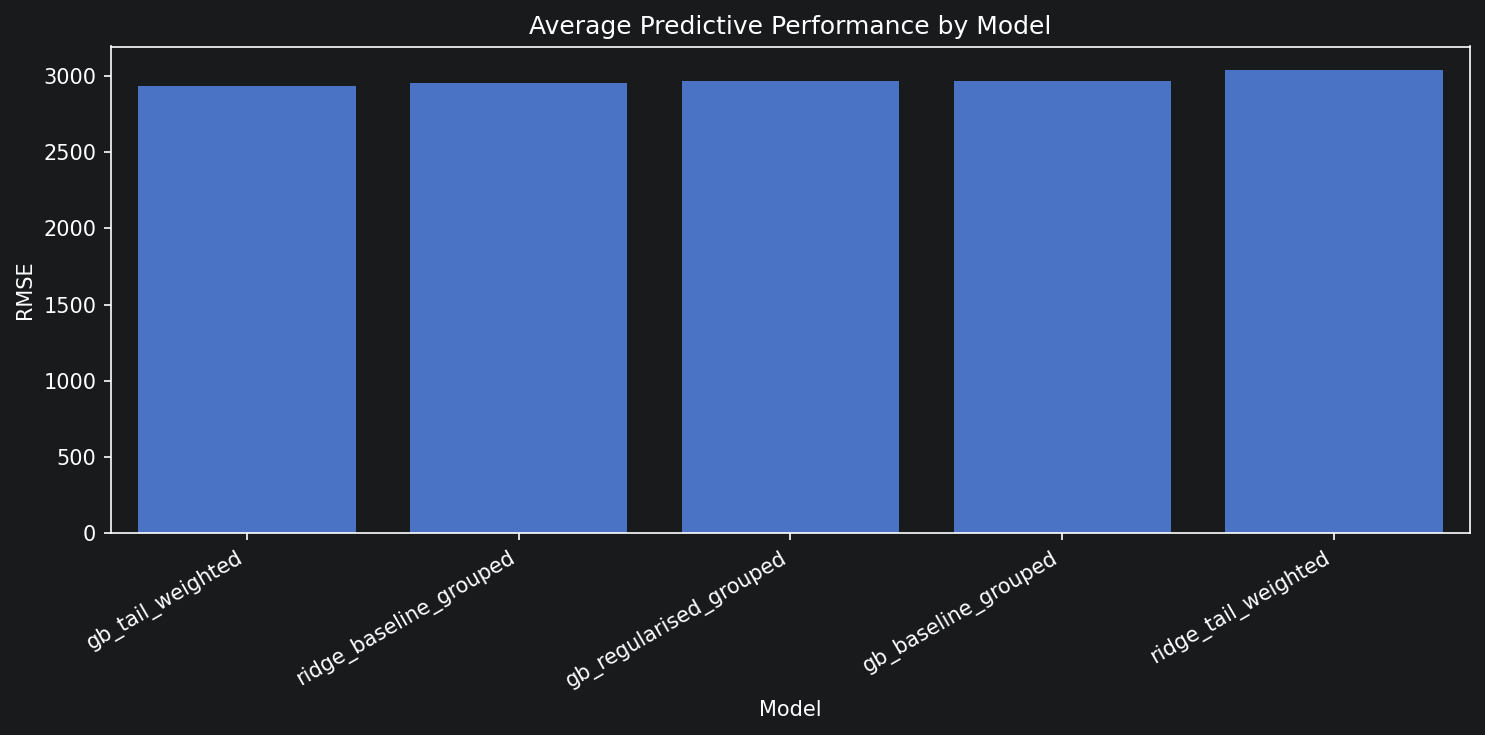

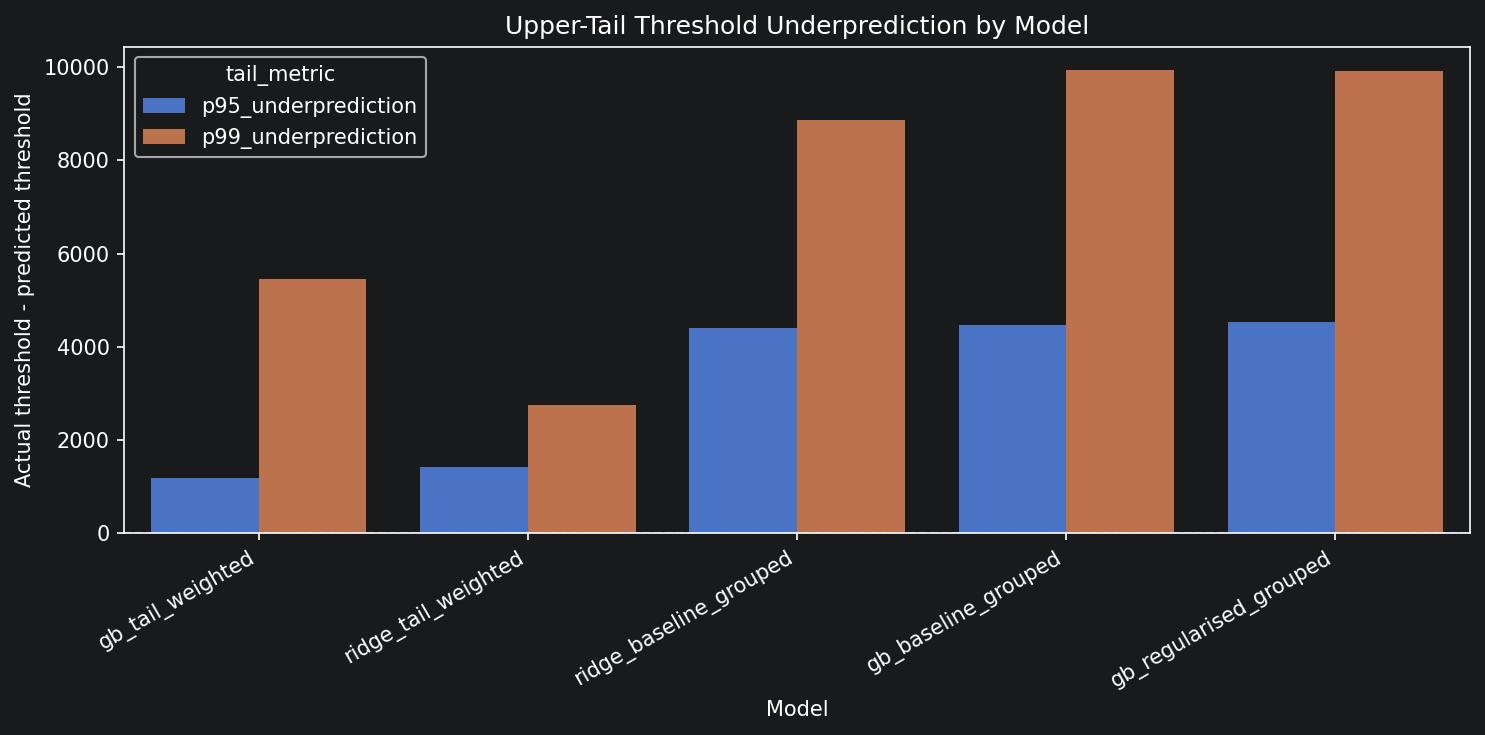

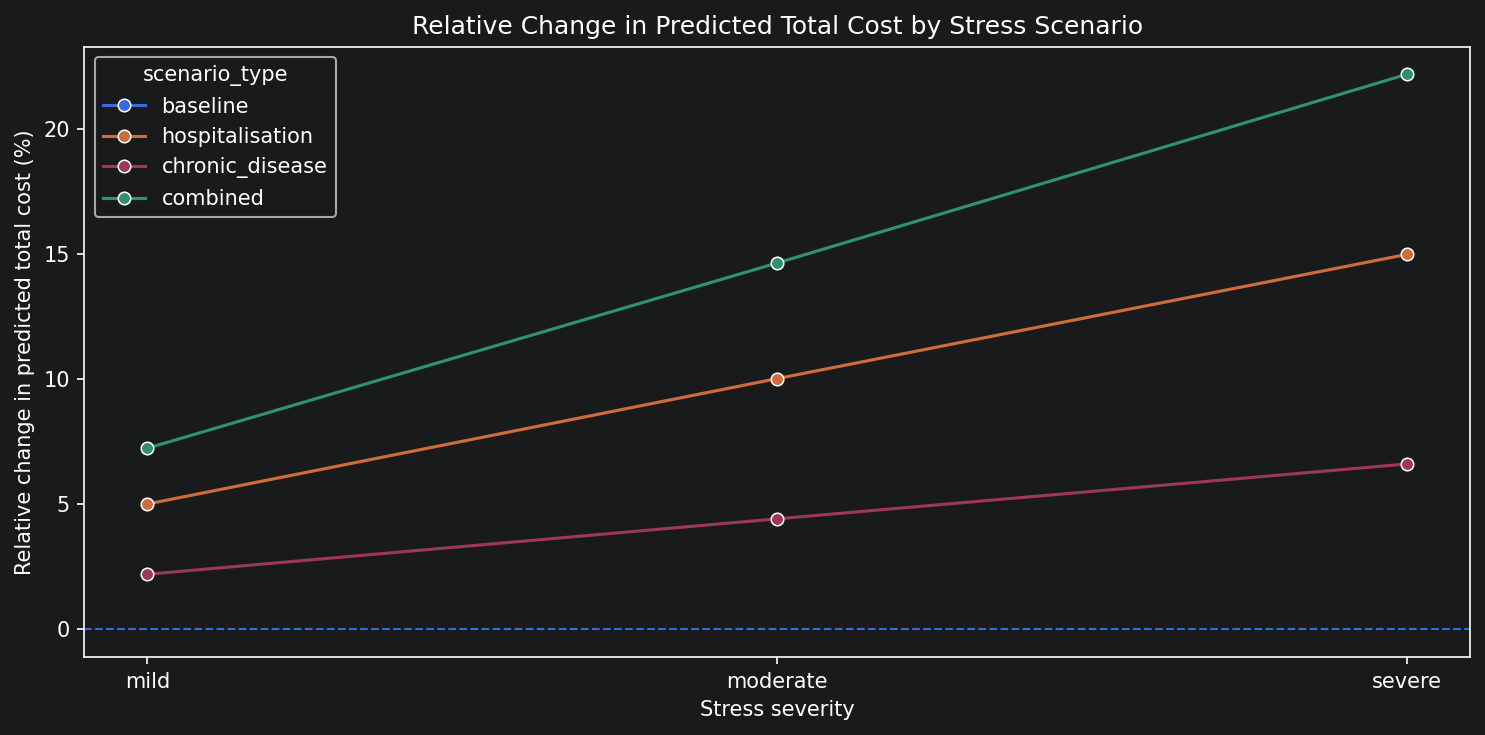

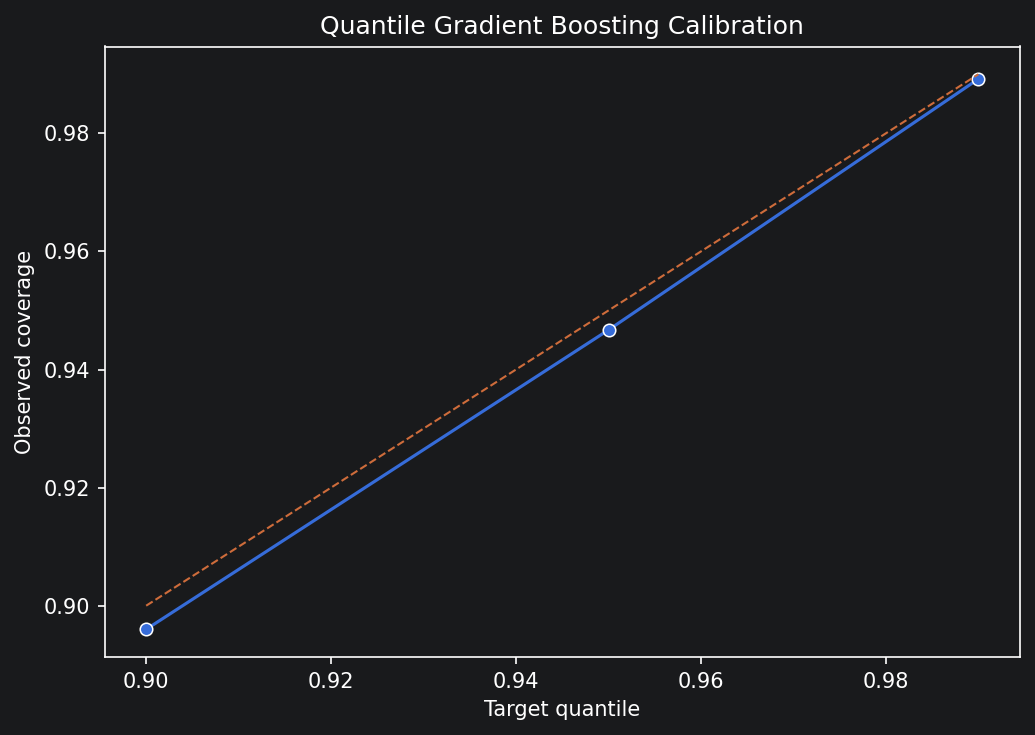

Saved figures:
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\average_predictive_performance_rmse.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\tail_threshold_underprediction.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\stress_total_cost_response.png
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\Figures\quantile_model_calibration.png


In [12]:
plot_dir = OUTPUT_09_DIR / "Figures"
plot_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5), dpi=150)
sns.barplot(
    data=final_average_model_performance_df,
    x="model_name",
    y="RMSE",
)
plt.title("Average Predictive Performance by Model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
average_performance_plot_path = plot_dir / "average_predictive_performance_rmse.png"
plt.savefig(average_performance_plot_path, bbox_inches="tight")
plt.show()

underprediction_plot_df = final_tail_risk_performance_df.melt(
    id_vars=["model_name"],
    value_vars=["p95_underprediction", "p99_underprediction"],
    var_name="tail_metric",
    value_name="underprediction",
)

plt.figure(figsize=(10, 5), dpi=150)
sns.barplot(
    data=underprediction_plot_df,
    x="model_name",
    y="underprediction",
    hue="tail_metric",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Upper-Tail Threshold Underprediction by Model")
plt.xlabel("Model")
plt.ylabel("Actual threshold - predicted threshold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
tail_underprediction_plot_path = plot_dir / "tail_threshold_underprediction.png"
plt.savefig(tail_underprediction_plot_path, bbox_inches="tight")
plt.show()

stress_plot_df = final_stress_aggregate_response_df[
    final_stress_aggregate_response_df["scenario_type"].astype(str) != "baseline"
    ].copy()

plt.figure(figsize=(10, 5), dpi=150)
sns.lineplot(
    data=stress_plot_df,
    x="severity",
    y="total_predicted_cost_pct_change_percent",
    hue="scenario_type",
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Relative Change in Predicted Total Cost by Stress Scenario")
plt.xlabel("Stress severity")
plt.ylabel("Relative change in predicted total cost (%)")
plt.tight_layout()
stress_cost_response_plot_path = plot_dir / "stress_total_cost_response.png"
plt.savefig(stress_cost_response_plot_path, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 5), dpi=150)
sns.lineplot(
    data=final_quantile_model_diagnostics_df,
    x="target_quantile",
    y="observed_coverage",
    marker="o",
)
plt.plot([0.90, 0.99], [0.90, 0.99], linestyle="--", linewidth=1)
plt.title("Quantile Gradient Boosting Calibration")
plt.xlabel("Target quantile")
plt.ylabel("Observed coverage")
plt.tight_layout()
quantile_calibration_plot_path = plot_dir / "quantile_model_calibration.png"
plt.savefig(quantile_calibration_plot_path, bbox_inches="tight")
plt.show()

print("Saved figures:")
for path in [
    average_performance_plot_path,
    tail_underprediction_plot_path,
    stress_cost_response_plot_path,
    quantile_calibration_plot_path,
]:
    print(path)

In [13]:
exported_paths = [save_final_table(final_average_model_performance_df, "final_average_model_performance.csv"),
                  save_final_table(final_tail_risk_performance_df, "final_tail_risk_performance.csv"),
                  save_final_table(final_quantile_model_diagnostics_df, "final_quantile_model_diagnostics.csv"),
                  save_final_table(final_quantile_crossing_summary_df, "final_quantile_crossing_summary.csv"),
                  save_final_table(final_stress_aggregate_response_df, "final_stress_aggregate_response.csv"),
                  save_final_table(final_stress_tail_response_df, "final_stress_tail_response.csv"),
                  save_final_table(selected_model_summary_df, "selected_model_summary.csv"),
                  save_final_table(project_summary_df, "research_question_summary.csv")]

workbook_path = OUTPUT_09_DIR / "final_results_tables.xlsx"

with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    final_average_model_performance_df.to_excel(writer, sheet_name="average_performance", index=False)
    final_tail_risk_performance_df.to_excel(writer, sheet_name="tail_risk", index=False)
    final_quantile_model_diagnostics_df.to_excel(writer, sheet_name="quantile_diagnostics", index=False)
    final_quantile_crossing_summary_df.to_excel(writer, sheet_name="quantile_crossing", index=False)
    final_stress_aggregate_response_df.to_excel(writer, sheet_name="stress_aggregate", index=False)
    final_stress_tail_response_df.to_excel(writer, sheet_name="stress_tail", index=False)
    selected_model_summary_df.to_excel(writer, sheet_name="model_selection", index=False)
    project_summary_df.to_excel(writer, sheet_name="rq_summary", index=False)

exported_paths.append(workbook_path)

print("Saved final outputs:")
for path in exported_paths:
    print(path)

Saved final outputs:
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\final_average_model_performance.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\final_tail_risk_performance.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\final_quantile_model_diagnostics.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\final_quantile_crossing_summary.csv
C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\09_final_model_comparison_and_results_tables\final_stress_aggregate_response.csv
C:\Users\maxfa\OneDrive\Documents\Universi